In [1]:
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, recall_score, precision_score, f1_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier

# Hide warnings in the notebook
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
test_url = 'https://raw.githubusercontent.com/Hertfordshire-Data-Science-Hackathon/Group-F-RMDS-Hackathon/refs/heads/main/dataset_A_testing.csv'


training_url = 'https://raw.githubusercontent.com/Hertfordshire-Data-Science-Hackathon/Group-F-RMDS-Hackathon/refs/heads/main/dataset_A_training.csv'

In [3]:
'''
  Import dataset for training and test for analysis
'''

# Training dataset
df_vaccine = pd.read_csv(training_url)

# Test dataset
df_vaccine_test = pd.read_csv(test_url)

In [4]:
df_vaccine.set_index('respondent_id', inplace=True)
df_vaccine_test.set_index('respondent_id', inplace=True)

In [5]:
# Preview
df_vaccine.sample(10)

,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
1670,2.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,wholesale,1
1876,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,utilities,1
980,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,NaN,...,Female,NaN,NaN,NaN,NaN,Non-MSA,1.0,2.0,NaN,0
1739,3.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN,1
1374,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,Non-MSA,1.0,0.0,NaN,1
2279,3.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,Female,NaN,Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,1
4244,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Female,"> $75,000",Married,Rent,Employed,Non-MSA,1.0,3.0,science,1
4736,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Employed,"MSA, Principle City",2.0,1.0,wholesale,0
990,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Rent,Unemployed,"MSA, Principle City",1.0,2.0,NaN,1


# **EDA and Pre-processing**

In [6]:
# Shape of the dataset
print(f'Data has {df_vaccine.shape[0]} rows and {df_vaccine.shape[1]} columns')

Data has 4756 rows and 30 columns


In [7]:
# General overview of the dataset
df_vaccine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4756 entries, 1 to 4756
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   flu_concern                  4744 non-null   float64
 1   flu_knowledge                4733 non-null   float64
 2   behavioral_antiviral_meds    4742 non-null   float64
 3   behavioral_avoidance         4724 non-null   float64
 4   behavioral_face_mask         4753 non-null   float64
 5   behavioral_wash_hands        4748 non-null   float64
 6   behavioral_large_gatherings  4747 non-null   float64
 7   behavioral_outside_home      4747 non-null   float64
 8   behavioral_touch_face        4737 non-null   float64
 9   doctor_recc_seasonal         4435 non-null   float64
 10  chronic_med_condition        4568 non-null   float64
 11  child_under_6_months         4604 non-null   float64
 12  health_worker                4607 non-null   float64
 13  health_insurance       

In [8]:
df_vaccine.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
flu_concern,4744.0,1.64,0.92,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,1.29,0.62,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,0.05,0.22,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,0.73,0.44,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,0.07,0.26,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,0.84,0.37,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,0.37,0.48,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,0.34,0.47,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,0.69,0.46,0.0,0.0,1.0,1.0,1.0
doctor_recc_seasonal,4435.0,0.37,0.48,0.0,0.0,0.0,1.0,1.0


In [9]:
# Check for empty values
(df_vaccine.isnull().sum()/len(df_vaccine)) * 100.0

,0
flu_concern,0.252313
flu_knowledge,0.483600
behavioral_antiviral_meds,0.294365
behavioral_avoidance,0.672834
behavioral_face_mask,0.063078
behavioral_wash_hands,0.168209
behavioral_large_gatherings,0.189235
behavioral_outside_home,0.189235
behavioral_touch_face,0.399495
doctor_recc_seasonal,6.749369


In [10]:
# Check for duplicates in data
has_duplicates = df_vaccine.duplicated().sum()

print(f'{has_duplicates} duplicates found in the data')

# Drop duplicates if any
df_vaccine.drop_duplicates(keep='first', ignore_index=True, inplace=True)

0 duplicates found in the data


In [11]:
# seperate target from features
target = df_vaccine['seasonal_vaccine']
feature = df_vaccine.drop(columns=['seasonal_vaccine'], axis=1)

In [12]:
mice_imputer = IterativeImputer(random_state=42)
power_transformer = PowerTransformer(method="yeo-johnson")

In [13]:
# Separate numerical and categorical columns
numerical_cols = feature.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = feature.select_dtypes(include=["object", "category"]).columns

In [14]:
# Make column transformation
preprocessor = ColumnTransformer([
    ('imputer', mice_imputer, numerical_cols),
    ('transformer', power_transformer, numerical_cols),
    ('one-hot', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ], remainder = 'passthrough'
  )

In [15]:
# Define pipeline for sequencing
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

In [16]:
# Split dataset for model training
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size = 0.2, random_state=42)

In [17]:
# Create dictionary to store models
models = {
  'dtc': {
    'name': 'Decision Tree',
    'model': DecisionTreeClassifier(random_state=42),
    'params':{
      'model__criterion': ['gini','entropy'],
      'model__max_depth': [10, 30],
      'model__min_samples_split': [4, 10],
      'model__min_samples_leaf': [2, 4],
      'model__max_features': ['sqrt', 'log2', None]
    }
  },
  'lgbm': {
    'name': 'LightGBM',
    'model': LGBMClassifier(random_state=42, verbosity=-1,),
    'params':{
      'model__num_leaves': [15, 31],
      'model__min_child_samples': [50, 100],
      'model__max_depth': [5, 8, 12],
      'model__learning_rate': [0.01, 0.05],
      'model__n_estimators': [400, 1000, 2000],
      'model__feature_fraction':[0.8,0.9,1.0]
    }
  }
}


In [18]:
# Store f1-score of each tunned model for visualization
model_name = []
model_f1score = []

----------------------------------------------------------------------------------------------------
--> Decision Tree <--
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer',
                                                  IterativeImputer(random_state=42),
                                                  Index(['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'd...
      dtype='object')),
                                                 ('one-hot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent

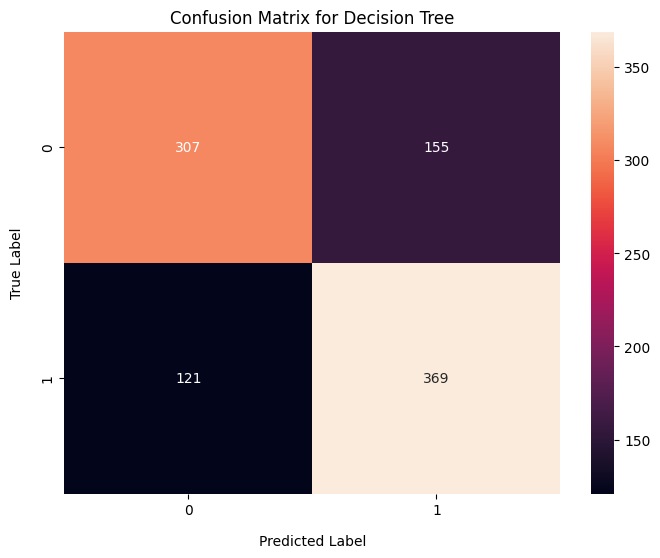




----------------------------------------------------------------------------------------------------
--> LightGBM <--
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer',
                                                  IterativeImputer(random_state=42),
                                                  Index(['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'd...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'census_msa',
       'employment_sector'],
      dtype='

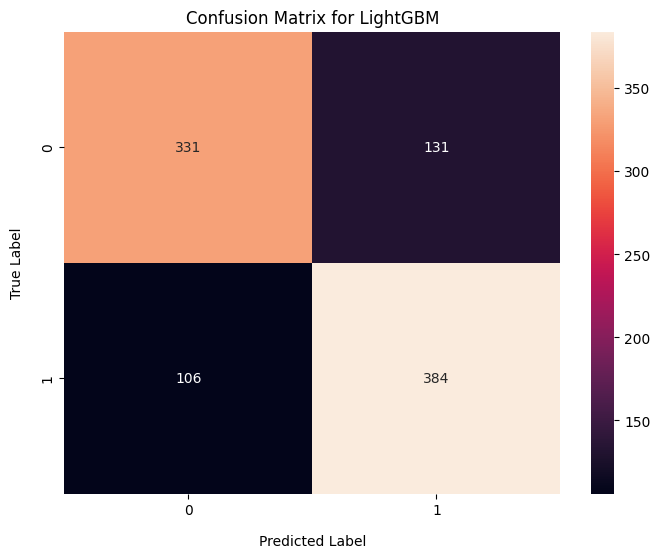

In [20]:
''' Training models by looping through the hyperparameter model dictionary while also outputing metrics'''

for abbr, model_dict in models.items():

  # Set the default model in the pipeline to the current running model
  pipeline.set_params(model = model_dict['model'])

  # Use the randomizedsearch CV to find the best model and perform the prediction
  model_search = RandomizedSearchCV(pipeline, model_dict['params'], n_iter=50,cv=5, scoring='f1', n_jobs=-1, random_state=42)

  # Fit data for training
  model_search.fit(X_train, y_train)

  # Find the best estimator from the randomizedsearchcv
  best_estimator = model_search.best_estimator_

  # Make prediction using
  y_pred = model_search.predict(X_test)
  y_pred_test = model_search.predict(df_vaccine_test)

  #-----------------------------------------------------------------

   # Store result of each model metrics for visualization
  model_name.append(model_dict['name'])
  model_f1score.append(f1_score(y_test,y_pred))

  # Get results to dataframe and save
  results = pd.DataFrame({
      'respondent_id' : df_vaccine_test.index,
      'seasonal_vaccine' : y_pred_test
  })

  results.to_csv(f'/content/{model_dict['name']}.csv', index=False)

  #-----------------------------------------------------------------

  # Show metrics
  print('-'*100)
  print(f'--> {model_dict['name']} <--')
  #print('\n')

  #Print the best estimator
  print(f'Best Estimator: {best_estimator}')

  print('-'*100)
  print(f'F1 score for {model_dict['name']}: {f1_score(y_test,y_pred)}')
  #-----------------------------------------------------------------

  # Print out the best parameter
  print('-'*100)
  print(f'--> Best paramter found for {model_dict['name']} --')
  print(best_estimator.named_steps['model'])

  # Add line break
  print('\n\n')

  # Plot the confusion matrix of the model
  cm = confusion_matrix(y_test,y_pred)
  plt.subplots(figsize=(8,6), dpi=100)
  sns.heatmap(cm,annot=True,fmt='d',cbar=True,)
  plt.xlabel('Predicted Label', labelpad=12)
  plt.ylabel('True Label', labelpad=12)
  plt.title(f'Confusion Matrix for {model_dict['name']}')
  plt.show()

  # Add line break
  print('\n\n')